In [92]:
import re
import string
import nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")


In [2]:
def load_data(path, file_type="csv", **kwargs):
    """
    Load a dataset from CSV or Excel.
    """
    
    if file_type == "csv":
        df = pd.read_csv(path, **kwargs)

    elif file_type in ["excel", "xlsx", "xls"]:
        df = pd.read_excel(path, **kwargs)

    else:
        raise ValueError("Unsupported file type. Use 'csv' or 'excel'.")

    return df

In [3]:
df = load_data(r"C:\Users\moham\Downloads\NLP_Cellula\NLP_Cellula_Internship\Week1\Cellula_1week_Mohamed_Eleraky\Data1\Data_6k_Final.csv")

print(df.head())

                                                text  Toxic Category
0                 A child playing in a sunny meadow.            Safe
1            A family enjoying a picnic in the park.            Safe
2         Police tape across a crime scene at night.  Violent Crimes
3  An emergency vehicle with flashing lights at a...  Violent Crimes
4     People walking through a peaceful city street.            Safe


## Exploring Data

In [4]:
def explore_text_data(
    df,
    text_columns=None,
    target_column=None
):

    dataset_overview = pd.DataFrame({
        "Metric": [
            "Rows",
            "Columns",
            "Missing Values",
            "Duplicate Rows",
        ],
        "Value": [
            len(df),
            len(df.columns),
            df.isnull().sum().sum(),
            df.duplicated().sum(),
        ]
    })

    # Column information
    column_info = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Unique Values": df.nunique(dropna=False).values,
        "Missing Values": df.isnull().sum().values,
        "Missing %": (
            df.isnull().mean() * 100
        ).round(2).values
    })

    print("\n" + "=" * 70)
    print("DATASET OVERVIEW")
    print("=" * 70)

    display(dataset_overview)

    print("\n" + "=" * 70)
    print("Columns Information:")
    print("=" * 70)

    display(column_info)

# Text information
    text_info = None
    if text_columns is not None:

        if isinstance(text_columns, str):
            text_columns = [text_columns]

        text_results = []

        for column in text_columns:
            # Convert only for analysis
            text = df[column].fillna("").astype(str)

            char_length = text.str.len()
            word_count = text.str.split().str.len()

            empty_count = (text.str.strip() == "").sum()
            duplicate_texts = text.duplicated().sum()

            text_results.append({
                "Column": column,
                "Unique Texts": text.nunique(),
                "Empty Texts": empty_count,
                "Empty %": round(
                    empty_count / len(text) * 100, 2
                ),
                "Duplicate Texts": duplicate_texts,
                "Duplicate %": round(
                    duplicate_texts / len(text) * 100, 2
                ),
                "Min Characters": char_length.min(),
                "Max Characters": char_length.max(),
                "Min Words": word_count.min(),
                "Max Words": word_count.max(),
                "Mean Words": round(
                    word_count.mean(), 2
                ),
                "Median Words": round(
                    word_count.median(), 2
                )
            })

        if text_results:
            text_info = pd.DataFrame(text_results, columns=text_results[0].keys())

            print("\n" + "=" * 70)
            print("TEXT ANALYSIS")
            print("=" * 70)

            display(text_info)

# Target information
    target_info = None
    if target_column is not None:

        if target_column not in df.columns:
            print(f"\nWarning: '{target_column}' not found.")
        else:
            target = df[target_column]

            target_info = pd.DataFrame({
                "Class": target.value_counts(
                    dropna=False
                ).index.astype(str),

                "Count": target.value_counts(
                    dropna=False
                ).values,

                "Percentage": (
                    target.value_counts(
                        normalize=True,
                        dropna=False
                    ) * 100
                ).round(2).values
            })

            print("\n" + "=" * 70)
            print("TARGET ANALYSIS")
            print("=" * 70)

            print(f"\nTarget: {target_column}")
            print(
                f"Unique Classes: "
                f"{target.nunique(dropna=False)}"
            )
            print(
                f"Missing Targets: "
                f"{target.isnull().sum()}"
            )

            display(target_info)

    return dataset_overview, column_info, text_info, target_info

In [5]:
dataset_overview, column_info, text_info, target_info = explore_text_data(
    df,
    text_columns=["text"],
    target_column="Toxic Category"
)


DATASET OVERVIEW


,Metric,Value
0,Rows,2021
1,Columns,2
2,Missing Values,0
3,Duplicate Rows,0



Columns Information:


,Column,Data Type,Unique Values,Missing Values,Missing %
0,text,object,2021,0,0.0
1,Toxic Category,object,4,0,0.0



TEXT ANALYSIS


,Column,Unique Texts,Empty Texts,Empty %,Duplicate Texts,Duplicate %,Min Characters,Max Characters,Min Words,Max Words,Mean Words,Median Words
0,text,2021,0,0.0,0,0.0,12,761,2,140,13.67,12.0



TARGET ANALYSIS

Target: Toxic Category
Unique Classes: 4
Missing Targets: 0


,Class,Count,Percentage
0,Safe,868,42.95
1,Violent Crimes,689,34.09
2,Non-Violent Crimes,234,11.58
3,unsafe,230,11.38


## Insights from the data

- first the data is ~2k rows after preprocessing
- data is unbalanced which will make a problem should handle it

## Data Cleaning

In [6]:
def Basic_clean_text(
    text,
    lowercase=True,
    remove_html=True,
    remove_urls=True,
    remove_emails=True,
    remove_mentions=True,
    remove_hashtags=True,
    remove_numbers=False,
    remove_punctuation=True,
    remove_extra_spaces=True,
    remove_newlines=True,
    remove_control_chars=True,
    normalize_repeated_chars=False,
    min_repeated_chars=3
):

    # Handle missing / invalid values
    if text is None:
        return ""

    if not isinstance(text, str):
        text = str(text)

    # Remove HTML
    if remove_html:
        text = re.sub(r"<[^>]+>", " ", text)

    # Remove / replace URLs
    if remove_urls:
        text = re.sub(
            r"https?://\S+|www\.\S+",
            " ",
            text
        )

    # Remove / replace emails
    if remove_emails:
        text = re.sub(
            r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
            " ",
            text
        )

    # Remove mentions
    if remove_mentions:
        text = re.sub(
            r"(?<!\w)@\w+",
            " ",
            text
        )

    # Handle hashtags
    if remove_hashtags:
        text = re.sub(
            r"(?<!\w)#\w+",
            " ",
            text
        )
    else:
        # Keep the hashtag word but remove '#'
        text = re.sub(
            r"#(\w+)",
            r"\1",
            text
        )

    # Remove numbers
    if remove_numbers:
        text = re.sub(r"\d+", " ", text)

    # Normalize repeated characters
    if normalize_repeated_chars:
        pattern = rf"(.)\1{{{min_repeated_chars},}}"
        text = re.sub(
            pattern,
            r"\1",
            text
        )

    # Remove punctuation
    if remove_punctuation:
        text = re.sub(
            r"[^\w\s]",
            " ",
            text,
            flags=re.UNICODE
        )

    # Remove newlines and tabs
    if remove_newlines:
        text = re.sub(r"[\r\n\t]+", " ", text)

    # Lowercase
    if lowercase:
        text = text.lower()

    # Normalize whitespace
    if remove_extra_spaces:
        text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

In [7]:
df["text"] = df["text"].apply(Basic_clean_text)

## Splittin data

In [8]:
df["Toxic Category"].value_counts()

Toxic Category
Safe                  868
Violent Crimes        689
Non-Violent Crimes    234
unsafe                230
Name: count, dtype: int64

In [9]:
X = df["text"]
y = df["Toxic Category"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

## Tokenization

In [44]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [45]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Get Max Len

In [57]:
lengths = X_train.apply(lambda x: len(x.split()))
print(lengths.describe())
print(lengths.quantile(0.95))

count    1414.000000
mean       13.895332
std         8.153191
min         3.000000
25%        10.000000
50%        12.000000
75%        15.000000
max       126.000000
Name: text, dtype: float64
27.34999999999991


In [58]:
MAX_LEN = 28
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

In [59]:
EMBED_DIM = 128
embedding_layer = Embedding(input_dim=10000, output_dim=EMBED_DIM, input_length=MAX_LEN)

In [60]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

num_classes = len(le.classes_)
print(le.classes_)

['Non-Violent Crimes' 'Safe' 'Violent Crimes' 'unsafe']


## Class Imbalance

In [61]:
classes = np.unique(y_train_enc)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

## Model Structure

In [ ]:
model = Sequential([
    embedding_layer,
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [104]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=1e-4
)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [105]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

## Model Training

In [106]:
history = model.fit(
    X_train_pad,
    y_train_enc,

    validation_data=(
        X_val_pad,
        y_val_enc
    ),

    epochs=100,
    batch_size=64,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.4863 - loss: 1.3681 - val_accuracy: 0.3102 - val_loss: 1.3209 - learning_rate: 0.0010
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6615 - loss: 0.9307 - val_accuracy: 0.3696 - val_loss: 1.7877 - learning_rate: 0.0010
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7803 - loss: 0.4576
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7823 - loss: 0.4559 - val_accuracy: 0.4785 - val_loss: 2.0000 - learning_rate: 0.0010
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9176 - loss: 0.2554 - val_accuracy: 0.4356 - val_loss: 2.2217 - learning_rate: 5.0000e-04
Epoch 5/100
21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9460 - loss: 0.1549
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9473 - loss: 0.1526 - 

## Model Evalaution

In [107]:
y_pred_prob = model.predict(X_test_pad)

y_train_pred = np.argmax(
    model.predict(X_train_pad, verbose=0),
    axis=1
)

y_val_pred = np.argmax(
    model.predict(X_val_pad, verbose=0),
    axis=1
)

y_test_pred = np.argmax(
    model.predict(X_test_pad, verbose=0),
    axis=1
)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [108]:
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred))

print(
    "Weighted F1:",
    f1_score(
        y_test_enc,
        y_test_pred,
        average="weighted"
    )
)

print(
    classification_report(
        y_test_enc,
        y_test_pred,
        target_names=le.classes_
    )
)

Accuracy: 0.34210526315789475
Weighted F1: 0.3636960597236856
                    precision    recall  f1-score   support

Non-Violent Crimes       0.17      0.03      0.05        35
              Safe       0.73      0.43      0.54       131
    Violent Crimes       0.46      0.21      0.29       104
            unsafe       0.14      0.74      0.24        34

          accuracy                           0.34       304
         macro avg       0.37      0.35      0.28       304
      weighted avg       0.51      0.34      0.36       304



## Confusion Matrix

In [109]:
cm_train = confusion_matrix(y_train_enc, y_train_pred)
cm_val = confusion_matrix(y_val_enc, y_val_pred)
cm_test = confusion_matrix(y_test_enc, y_test_pred)

class_names = le.classes_

In [110]:
def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

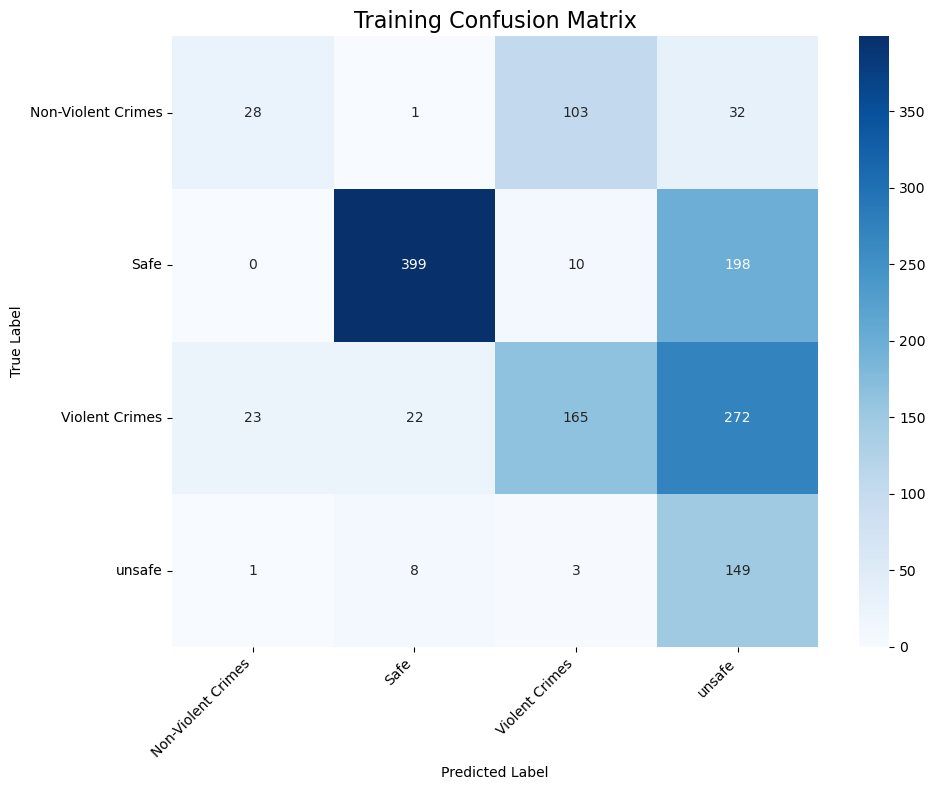

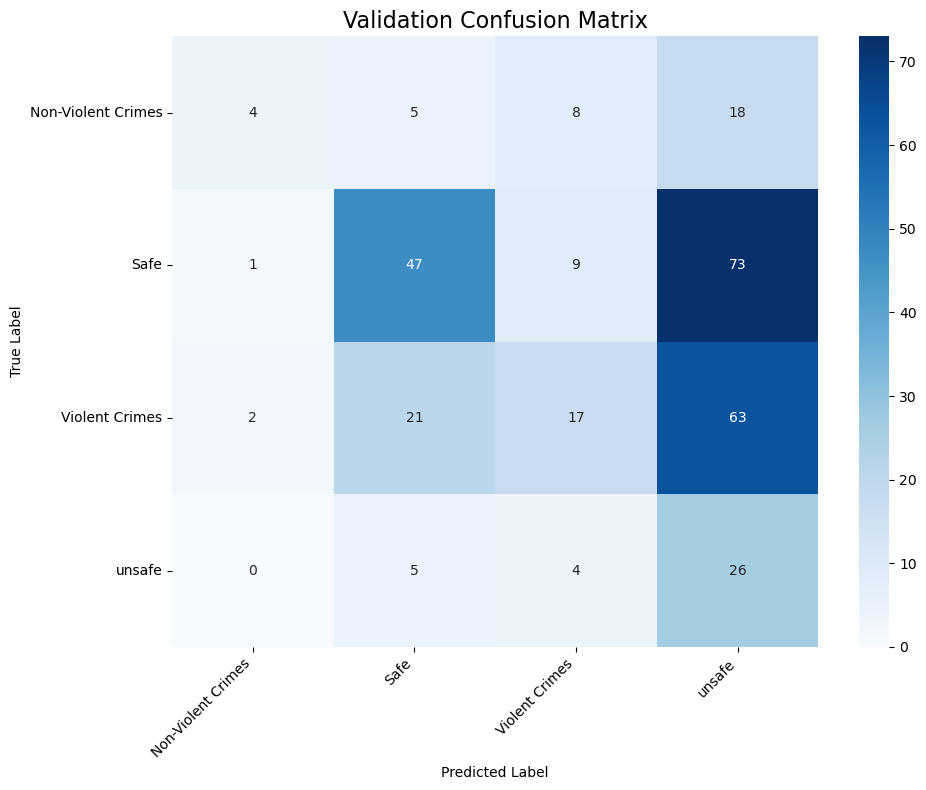

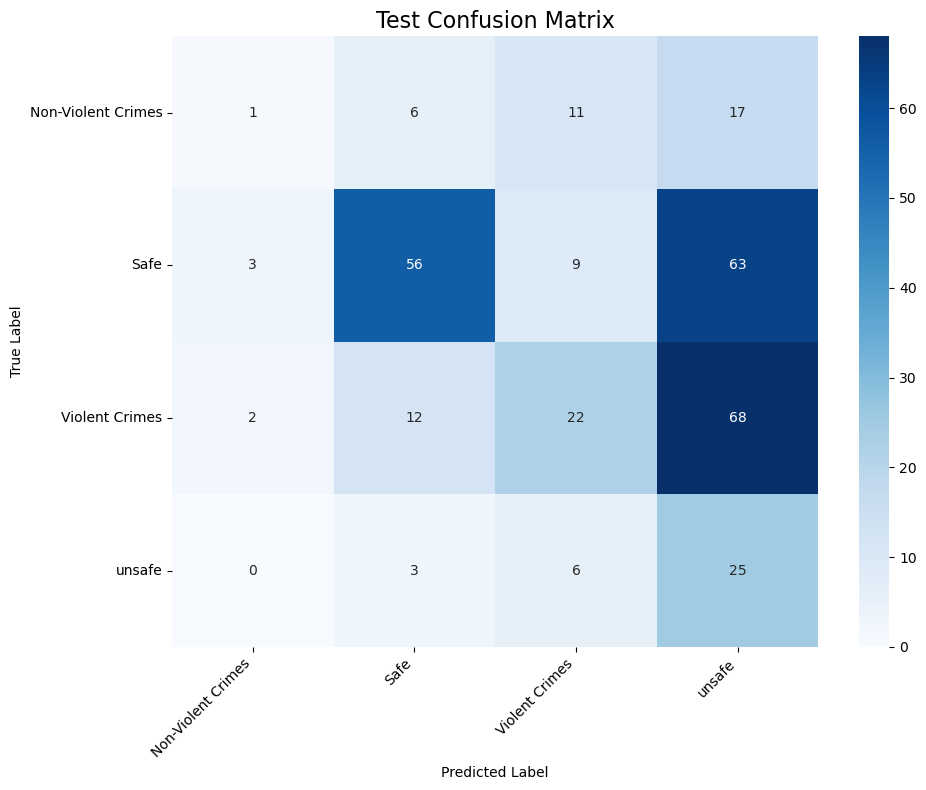

In [111]:
plot_confusion_matrix(cm_train, "Training Confusion Matrix")
plot_confusion_matrix(cm_val, "Validation Confusion Matrix")
plot_confusion_matrix(cm_test,"Test Confusion Matrix")